# Pandas Groupby & Aggregates

💡 **Este bloque realiza una operación con pandas, como selección o transformación de datos.**

In [1]:
import pandas as pd

📥 Los siguientes datos corresponden a información histórica de la acción de **Rivian Automotive** (símbolo bursátil: **RIVN**).

## 📊 ¿Qué tipo de datos son?

Es un conjunto de **datos financieros de mercado (bolsa de valores)** con precios diarios de la acción.

## 📁 Columnas del archivo

- **Symbol** → Símbolo de la acción (RIVN)
- **Date** → Fecha de cotización
- **Open** → Precio de apertura del día
- **High** → Precio más alto del día
- **Low** → Precio más bajo del día
- **Close** → Precio de cierre del día
- **Adj Close** → Precio de cierre ajustado (considera dividendos y splits)
- **Volume** → Número de acciones negociadas ese día

## 📌 Conclusión

Son **datos históricos del precio de una acción en la bolsa**, útiles para:

- 📈 Análisis financiero
- 📊 Visualizaciones con Pandas
- 📉 Análisis de tendencias
- 🤖 Modelos de predicción

In [3]:
carstocks = pd.read_csv("data/car_stocks.csv")

In [4]:
carstocks

,Symbol,Date,Open,High,Low,Close,Adj Close,Volume
0,RIVN,2021-11-10,106.750000,119.459999,95.199997,100.730003,100.730003,103679500
1,RIVN,2021-11-11,114.625000,125.000000,108.010002,122.989998,122.989998,83668200
2,RIVN,2021-11-12,128.645004,135.199997,125.250000,129.949997,129.949997,50437500
3,RIVN,2021-11-15,130.800003,152.529999,127.510002,149.360001,149.360001,64982300
4,RIVN,2021-11-16,163.800003,179.470001,153.779999,172.009995,172.009995,94036600
5,RIVN,2021-11-17,160.880005,163.000000,140.350006,146.070007,146.070007,71765600
6,RIVN,2021-11-18,136.809998,138.779999,120.150002,123.379997,123.379997,63603600
7,RIVN,2021-11-19,129.979996,139.899994,125.599998,128.600006,128.600006,49368200
8,RIVN,2021-11-22,123.879997,124.930000,106.910004,118.110001,118.110001,40993900
9,RIVN,2021-11-23,117.830002,124.000000,113.000000,119.849998,119.849998,24967900


### 📊 carstocks["Close"].mean()
Calcula el **promedio** (media aritmética) de todos los valores de la columna `Close`.

---

In [5]:
carstocks["Close"].mean()

np.float64(79.83897420512821)

### 📊 carstocks[carstocks["Symbol"] == "RIVN"]["Close"].mean()

1. **carstocks["Symbol"] == "RIVN"**
   Crea una condición para seleccionar solo las filas donde el símbolo sea `RIVN`.

2. **carstocks[ ... ]**
   Filtra el DataFrame y se queda únicamente con los registros de `RIVN`.

3. **["Close"]**
   Selecciona la columna `Close` (precio de cierre).

4. **.mean()**
   Calcula el promedio de esos precios filtrados.

📌 **Resultado:**
Devuelve el **precio promedio de cierre de la acción RIVN**.

In [78]:
carstocks[carstocks["Symbol"] == "RIVN"]["Close"].mean()

127.52307653846154

📌 **Resultado:**
Devuelve el **precio promedio de cierre de la acción GM**.

In [79]:
carstocks[carstocks["Symbol"] == "GM"]["Close"].mean()

62.16461546153845

📌 **Resultado:**
Devuelve el **precio promedio de cierre de la acción LCID**.

In [80]:
carstocks[carstocks["Symbol"] == "LCID"]["Close"].mean()

49.82923061538462

## Groupby Basics

### 📊 carstocks.groupby("Symbol")["Close"].mean()

1. **groupby("Symbol")**
   Agrupa los datos según el valor de la columna `Symbol`.

2. **["Close"]**
   Selecciona la columna `Close` (precio de cierre).

3. **.mean()**
   Calcula el promedio del precio de cierre para cada grupo.

📌 **Resultado:**
Devuelve el **precio promedio de cierre por cada símbolo de acción** en el DataFrame.

In [6]:
carstocks.groupby("Symbol")["Close"].mean()

Symbol
GM       62.164615
LCID     49.829231
RIVN    127.523077
Name: Close, dtype: float64

# 📥  Explorando grupos

In [82]:
titanic = pd.read_csv("data/titanic.csv")
titanic['age'] = titanic["age"].replace(['?'], [None]).astype('float')

💡 **Este bloque realiza una operación con pandas, como selección o transformación de datos.**

In [83]:
df = titanic[["pclass", "survived", "sex", "age"]]

📊 **Agrupamos los datos por una o más columnas para analizarlos por categoría.**

In [84]:
gbo = df.groupby(by="sex")

💡 **Este bloque realiza una operación con pandas, como selección o transformación de datos.**

In [85]:
gbo

💡 **Este bloque realiza una operación con pandas, como selección o transformación de datos.**

In [86]:
gbo.ngroups

2

💡 **Este bloque realiza una operación con pandas, como selección o transformación de datos.**

In [87]:
gbo.groups

{'female': [0, 2, 4, 6, 8, 11, 12, 13, 17, 18, 21, 23, 24, 27, 28, 32, 33, 35, 36, 41, 42, 43, 44, 48, 50, 55, 57, 59, 61, 63, 65, 66, 67, 69, 72, 73, 76, 78, 79, 82, 83, 85, 88, 90, 92, 95, 97, 98, 99, 102, 103, 104, 105, 107, 108, 111, 112, 113, 116, 117, 121, 122, 124, 127, 129, 130, 131, 134, 137, 139, 141, 144, 146, 149, 153, 155, 159, 160, 161, 163, 167, 168, 169, 176, 178, 180, 181, 182, 186, 187, 188, 190, 192, 193, 195, 198, 199, 204, 207, 208, ...], 'male': [1, 3, 5, 7, 9, 10, 14, 15, 16, 19, 20, 22, 25, 26, 29, 30, 31, 34, 37, 38, 39, 40, 45, 46, 47, 49, 51, 52, 53, 54, 56, 58, 60, 62, 64, 68, 70, 71, 74, 75, 77, 80, 81, 84, 86, 87, 89, 91, 93, 94, 96, 100, 101, 106, 109, 110, 114, 115, 118, 119, 120, 123, 125, 126, 128, 132, 133, 135, 136, 138, 140, 142, 143, 145, 147, 148, 150, 151, 152, 154, 156, 157, 158, 162, 164, 165, 166, 170, 171, 172, 173, 174, 175, 177, 179, 183, 184, 185, 189, 191, ...]}

💡 **Este bloque realiza una operación con pandas, como selección o transformación de datos.**

In [88]:
df

,pclass,survived,sex,age
0,1,1,female,29.0000
1,1,1,male,0.9167
2,1,0,female,2.0000
3,1,0,male,30.0000
4,1,0,female,25.0000
...,...,...,...,...
1304,3,0,female,14.5000
1305,3,0,female,NaN
1306,3,0,male,26.5000
1307,3,0,male,27.0000


📊 **Agrupamos los datos por una o más columnas para analizarlos por categoría.**

In [89]:
df.groupby("age").groups

{0.1667: [763], 0.3333: [747], 0.4167: [1240], 0.6667: [427], 0.75: [657, 658, 1111], 0.8333: [359, 548, 611], 0.9167: [1, 590], 1.0: [339, 478, 492, 762, 826, 895, 937, 1048, 1101, 1187], 2.0: [2, 514, 540, 587, 624, 866, 1096, 1103, 1144, 1156, 1209, 1230], 3.0: [479, 515, 549, 641, 734, 1098, 1112], 4.0: [94, 340, 588, 622, 894, 916, 934, 1142, 1189, 1206], 5.0: [591, 639, 643, 659, 794], 6.0: [273, 430, 623, 678, 1025, 1097], 7.0: [434, 1102, 1143, 1256], 8.0: [377, 385, 398, 541, 1099, 1145], 9.0: [627, 640, 679, 733, 807, 820, 825, 1082, 1208, 1257], 10.0: [828, 1141, 1207, 1265], 11.0: [54, 628, 827, 855], 11.5: [1263], 12.0: [341, 582, 1056], 13.0: [249, 501, 601, 642, 653], 14.0: [55, 513, 569, 830, 1057, 1105, 1236, 1279], 14.5: [1171, 1304], 15.0: [193, 350, 792, 1007, 1047, 1300], 16.0: [159, 187, 195, 416, 510, 602, 604, 709, 761, 787, 810, 818, 829, 1093, 1104, 1161, 1232, 1244, 1275], 17.0: [53, 92, 229, 295, 390, 458, 482, 625, 650, 700, 701, 738, 740, 755, 772, 791, 84

📊 **Agrupamos los datos por una o más columnas para analizarlos por categoría.**

In [90]:
df.groupby("age").first()

,pclass,survived,sex
age,,,
0.1667,3,1,female
0.3333,3,0,male
0.4167,3,1,male
0.6667,2,1,male
0.7500,3,1,female
...,...,...,...
70.5000,3,0,male
71.0000,1,0,male
74.0000,3,0,male


💡 **Este bloque realiza una operación con pandas, como selección o transformación de datos.**

In [91]:
gbo.get_group("male")

,pclass,survived,sex,age
1,1,1,male,0.9167
3,1,0,male,30.0000
5,1,1,male,48.0000
7,1,0,male,39.0000
9,1,0,male,71.0000
...,...,...,...,...
1302,3,0,male,NaN
1303,3,0,male,NaN
1306,3,0,male,26.5000
1307,3,0,male,27.0000


💡 **Este bloque realiza una operación con pandas, como selección o transformación de datos.**

In [92]:
for name, group in gbo:
    print(name)
    print("----------")
    print(group)

female
----------
      pclass  survived     sex   age
0          1         1  female  29.0
2          1         0  female   2.0
4          1         0  female  25.0
6          1         1  female  63.0
8          1         1  female  53.0
...      ...       ...     ...   ...
1286       3         1  female  38.0
1290       3         1  female  47.0
1300       3         1  female  15.0
1304       3         0  female  14.5
1305       3         0  female   NaN

[466 rows x 4 columns]
male
----------
      pclass  survived   sex      age
1          1         1  male   0.9167
3          1         0  male  30.0000
5          1         1  male  48.0000
7          1         0  male  39.0000
9          1         0  male  71.0000
...      ...       ...   ...      ...
1302       3         0  male      NaN
1303       3         0  male      NaN
1306       3         0  male  26.5000
1307       3         0  male  27.0000
1308       3         0  male  29.0000

[843 rows x 4 columns]


🧮 **Calculamos el promedio de los valores agrupados.**

In [93]:
gbo["age"].mean()

sex
female    28.687071
male      30.585233
Name: age, dtype: float64

📈 **Obtenemos el valor máximo por grupo.**

In [94]:
gbo["age"].max()

sex
female    76.0
male      80.0
Name: age, dtype: float64

🧮 **Calculamos el promedio de los valores agrupados.**

<Axes: title={'center': 'Average Age By Sex'}, xlabel='sex'>

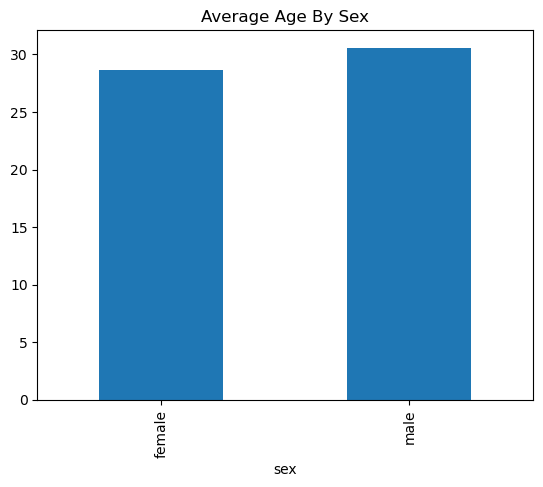

In [95]:
gbo["age"].mean().plot(kind="bar", title="Average Age By Sex")

📊 **Agrupamos los datos por una o más columnas para analizarlos por categoría.**

In [96]:
titanic.groupby("pclass")["age"].mean()

pclass
1    39.159918
2    29.506705
3    24.816367
Name: age, dtype: float64

📊 **Agrupamos los datos por una o más columnas para analizarlos por categoría.**

In [97]:
titanic.groupby("sex")["pclass"].mean()

sex
female    2.154506
male      2.372479
Name: pclass, dtype: float64

📊 **Agrupamos los datos por una o más columnas para analizarlos por categoría.**

In [98]:
titanic.groupby("sex").mean(numeric_only=True)

,pclass,survived,age,sibsp,parch
sex,,,,,
female,2.154506,0.727468,28.687071,0.652361,0.633047
male,2.372479,0.190985,30.585233,0.413998,0.247924


📊 **Agrupamos los datos por una o más columnas para analizarlos por categoría.**

In [99]:
titanic.groupby("sex").median(numeric_only=True)

,pclass,survived,age,sibsp,parch
sex,,,,,
female,2.0,1.0,27.0,0.0,0.0
male,3.0,0.0,28.0,0.0,0.0


📊 **Agrupamos los datos por una o más columnas para analizarlos por categoría.**

In [100]:
carstocks.groupby("Symbol")["High"].max()

Symbol
GM       65.180000
LCID     57.750000
RIVN    179.470001
Name: High, dtype: float64

## Agg

📊 **Agrupamos los datos por una o más columnas para analizarlos por categoría.**

In [101]:
titanic.groupby("sex")["age"].agg("min")

sex
female    0.1667
male      0.3333
Name: age, dtype: float64

📊 **Agrupamos los datos por una o más columnas para analizarlos por categoría.**

In [102]:
titanic.groupby("sex")["age"].agg(["min", "max", "mean", "median"])

,min,max,mean,median
sex,,,,
female,0.1667,76.0,28.687071,27.0
male,0.3333,80.0,30.585233,28.0


📊 **Agrupamos los datos por una o más columnas para analizarlos por categoría.**

In [103]:
titanic.groupby("sex").agg(["min", "max"])

pclass     survived                                  name  \
          min max      min max                               min   
sex                                                                
female      1   3        0   1  Abbott, Mrs. Stanton (Rosa Hunt)   
male        1   3        0   1               Abbing, Mr. Anthony   

                                                          age       sibsp      \
                                                  max     min   max   min max   
sex                                                                             
female  del Carlo, Mrs. Sebastiano (Argenia Genovesi)  0.1667  76.0     0   8   
male                      van Melkebeke, Mr. Philemon  0.3333  80.0     0   8   

        ... cabin     embarked     boat     body     home.dest  \
        ...   min max      min max  min max  min max       min   
sex     ...                                                      
female  ...     ?  G6        ?   S    1   D  206   ?         ?   
male    ...     ?   T        C   S    1   D    1   ?         ?   

                             
                        max  
sex                          
female  Zurich, Switzerland  
male    Zurich, Switzerland  

[2 rows x 26 columns]

📊 **Agrupamos los datos por una o más columnas para analizarlos por categoría.**

In [104]:
titanic.groupby("sex").agg({"age": ["min", "max"], "pclass": "mean"})

age          pclass
           min   max      mean
sex                           
female  0.1667  76.0  2.154506
male    0.3333  80.0  2.372479

📊 **Agrupamos los datos por una o más columnas para analizarlos por categoría.**

In [105]:
carstocks.groupby("Symbol").agg({"Open": "mean", "Close": "mean", "Volume": ["mean", "sum"]})

Open       Close        Volume            
              mean        mean          mean         sum
Symbol                                                  
GM       61.937693   62.164615  2.025259e+07   263283700
LCID     48.761538   49.829231  1.081098e+08  1405427200
RIVN    127.710000  127.523077  5.252395e+07   682811400

📊 **Agrupamos los datos por una o más columnas para analizarlos por categoría.**

In [106]:
def range(s):
    return s.max() - s.min()
    
titanic.groupby("pclass")["age"].agg(["min", "max", range])

,min,max,range
pclass,,,
1,0.9167,80.0,79.0833
2,0.6667,70.0,69.3333
3,0.1667,74.0,73.8333


🔢 **Contamos la cantidad de elementos por grupo.**

In [107]:
titanic["age"].size - titanic["age"].count()

263

📊 **Agrupamos los datos por una o más columnas para analizarlos por categoría.**

In [108]:
def count_nulls(s):
    return s.size - s.count()

titanic.groupby("pclass")["age"].agg(count_nulls)

pclass
1     39
2     16
3    208
Name: age, dtype: int64

📊 **Agrupamos los datos por una o más columnas para analizarlos por categoría.**

In [109]:
carstocks.groupby("Symbol").agg({"Open": ["min", "max"],"Close": ["min", "max"], })

Open                   Close            
               min         max         min         max
Symbol                                                
GM       57.849998   64.330002   59.270000   64.610001
LCID     42.299999   56.200001   40.750000   55.520000
RIVN    106.750000  163.800003  100.730003  172.009995

📊 **Agrupamos los datos por una o más columnas para analizarlos por categoría.**

In [110]:
carstocks.groupby("Symbol").agg(
    min_open=("Open", "min"),
    max_open=("Open", "max"),
    min_close=("Close", "min"),
    max_close=("Close", "max")
)

,min_open,max_open,min_close,max_close
Symbol,,,,
GM,57.849998,64.330002,59.270000,64.610001
LCID,42.299999,56.200001,40.750000,55.520000
RIVN,106.750000,163.800003,100.730003,172.009995


📊 **Agrupamos los datos por una o más columnas para analizarlos por categoría.**

In [111]:
carstocks.groupby("Symbol", as_index=False).agg({
    "Open": ["min", "max"],
    "Close": ["min", "max"], 
})

Symbol        Open                   Close            
                 min         max         min         max
0     GM   57.849998   64.330002   59.270000   64.610001
1   LCID   42.299999   56.200001   40.750000   55.520000
2   RIVN  106.750000  163.800003  100.730003  172.009995

📊 **Agrupamos los datos por una o más columnas para analizarlos por categoría.**

In [112]:
carstocks.groupby("Symbol").agg({
    "Open": ["min", "max"],
    "Close": ["min", "max"], 
})

Open                   Close            
               min         max         min         max
Symbol                                                
GM       57.849998   64.330002   59.270000   64.610001
LCID     42.299999   56.200001   40.750000   55.520000
RIVN    106.750000  163.800003  100.730003  172.009995

## Grouping By Multiple Columns & Multi Indexes

📊 **Agrupamos los datos por una o más columnas para analizarlos por categoría.**

In [113]:
titanic.groupby("sex")["age"].mean()

sex
female    28.687071
male      30.585233
Name: age, dtype: float64

📊 **Agrupamos los datos por una o más columnas para analizarlos por categoría.**

In [114]:
titanic.groupby(["sex", "pclass", "survived"])["age"].mean()

sex     pclass  survived
female  1       0           35.200000
                1           37.109375
        2       0           34.090909
                1           26.711051
        3       0           23.418750
                1           20.814815
male    1       0           43.658163
                1           36.168240
        2       0           33.092593
                1           17.449274
        3       0           26.679598
                1           22.436441
Name: age, dtype: float64

📊 **Agrupamos los datos por una o más columnas para analizarlos por categoría.**

In [115]:
titanic.groupby(["sex", "pclass"]).mean(numeric_only=True)

survived        age     sibsp     parch
sex    pclass                                         
female 1       0.965278  37.037594  0.555556  0.472222
       2       0.886792  27.499191  0.500000  0.650943
       3       0.490741  22.185307  0.791667  0.731481
male   1       0.340782  41.029250  0.340782  0.279330
       2       0.146199  30.815401  0.327485  0.192982
       3       0.152130  25.962273  0.470588  0.255578

💡 **Este bloque realiza una operación con pandas, como selección o transformación de datos.**

In [116]:
titanic.head()

,pclass,survived,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked,boat,body,home.dest
0,1,1,"Allen, Miss. Elisabeth Walton",female,29.0000,0,0,24160,211.3375,B5,S,2,?,"St Louis, MO"
1,1,1,"Allison, Master. Hudson Trevor",male,0.9167,1,2,113781,151.55,C22 C26,S,11,?,"Montreal, PQ / Chesterville, ON"
2,1,0,"Allison, Miss. Helen Loraine",female,2.0000,1,2,113781,151.55,C22 C26,S,?,?,"Montreal, PQ / Chesterville, ON"
3,1,0,"Allison, Mr. Hudson Joshua Creighton",male,30.0000,1,2,113781,151.55,C22 C26,S,?,135,"Montreal, PQ / Chesterville, ON"
4,1,0,"Allison, Mrs. Hudson J C (Bessie Waldo Daniels)",female,25.0000,1,2,113781,151.55,C22 C26,S,?,?,"Montreal, PQ / Chesterville, ON"


📊 **Agrupamos los datos por una o más columnas para analizarlos por categoría.**

In [118]:
df = titanic.groupby(["sex", "pclass"]).mean(numeric_only=True)

💡 **Este bloque realiza una operación con pandas, como selección o transformación de datos.**

In [119]:
df

survived        age     sibsp     parch
sex    pclass                                         
female 1       0.965278  37.037594  0.555556  0.472222
       2       0.886792  27.499191  0.500000  0.650943
       3       0.490741  22.185307  0.791667  0.731481
male   1       0.340782  41.029250  0.340782  0.279330
       2       0.146199  30.815401  0.327485  0.192982
       3       0.152130  25.962273  0.470588  0.255578

💡 **Este bloque realiza una operación con pandas, como selección o transformación de datos.**

In [120]:
df.loc[[("male", 3)]]

,,survived,age,sibsp,parch
sex,pclass,,,,
male,3,0.15213,25.962273,0.470588,0.255578


💡 **Este bloque realiza una operación con pandas, como selección o transformación de datos.**

In [121]:
titanic.loc[[1,2]]

,pclass,survived,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked,boat,body,home.dest
1,1,1,"Allison, Master. Hudson Trevor",male,0.9167,1,2,113781,151.55,C22 C26,S,11,?,"Montreal, PQ / Chesterville, ON"
2,1,0,"Allison, Miss. Helen Loraine",female,2.0000,1,2,113781,151.55,C22 C26,S,?,?,"Montreal, PQ / Chesterville, ON"


💡 **Este bloque realiza una operación con pandas, como selección o transformación de datos.**

In [122]:
df.loc[[("female", 3), ("male", 1)]]

,,survived,age,sibsp,parch
sex,pclass,,,,
female,3,0.490741,22.185307,0.791667,0.731481
male,1,0.340782,41.029250,0.340782,0.279330
